## Baltic Sea egg particles backtracking 

We use OceanParcels to backtrack the cod-larvae eggs we found in the ALKOR630 cruise from the 5th to 17th of April 2025

In [23]:
##import packages
from parcels import ParticleSet
from parcels import JITParticle
from parcels import AdvectionRK4_3D
from parcels import AdvectionRK4
from parcels import Geographic
from datetime import timedelta
import numpy as np
from parcels import FieldSet
from glob import glob
import xarray as xr
import pandas as pd
import cartopy 
from xhistogram.xarray import histogram as xhist
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [5]:
path1= '/gxfs_work/geomar/smomw662/ALKOR630/ALKOR630//data/'
fn = 'cmems_mod_bal_phy_anfc_P1D-m_uo-vo-so_9.04E-30.21E_53.01N-65.89N_0.50m_2025-03-01-2025-04-17.nc'
ds = xr.open_dataset(path1+fn)
ds

<xarray.Dataset> Size: 340MB
Dimensions:    (depth: 1, latitude: 774, longitude: 763, time: 48)
Coordinates:
  * depth      (depth) float32 4B 0.5016
  * latitude   (latitude) float32 3kB 53.01 53.02 53.04 ... 65.86 65.87 65.89
  * longitude  (longitude) float32 3kB 9.042 9.069 9.097 ... 30.15 30.18 30.21
  * time       (time) datetime64[ns] 384B 2025-03-01 2025-03-02 ... 2025-04-17
Data variables:
    uo         (time, depth, latitude, longitude) float32 113MB ...
    vo         (time, depth, latitude, longitude) float32 113MB ...
    so         (time, depth, latitude, longitude) float32 113MB ...
Attributes: (12/19)
    Conventions:               CF-1.0
    comment:                   Data on cropped native product grid. Horizonta...
    compression:               yes
    contact:                   servicedesk.cmems@mercator-ocean.eu
    creation_date:             2024-11-25 17:05:09
    easternmost_longitude:     30.208656311035156
    ...                        ...
    southernmost_latitude:     53.008296966552734
    start_date:                2024-11-30 12:00:00
    stop_date:                 2024-11-30 12:00:00
    title:                     CMEMS NEMO daily integrated model fields
    westernmost_longitude:     9.041582107543945
    copernicusmarine_version:  1.3.5

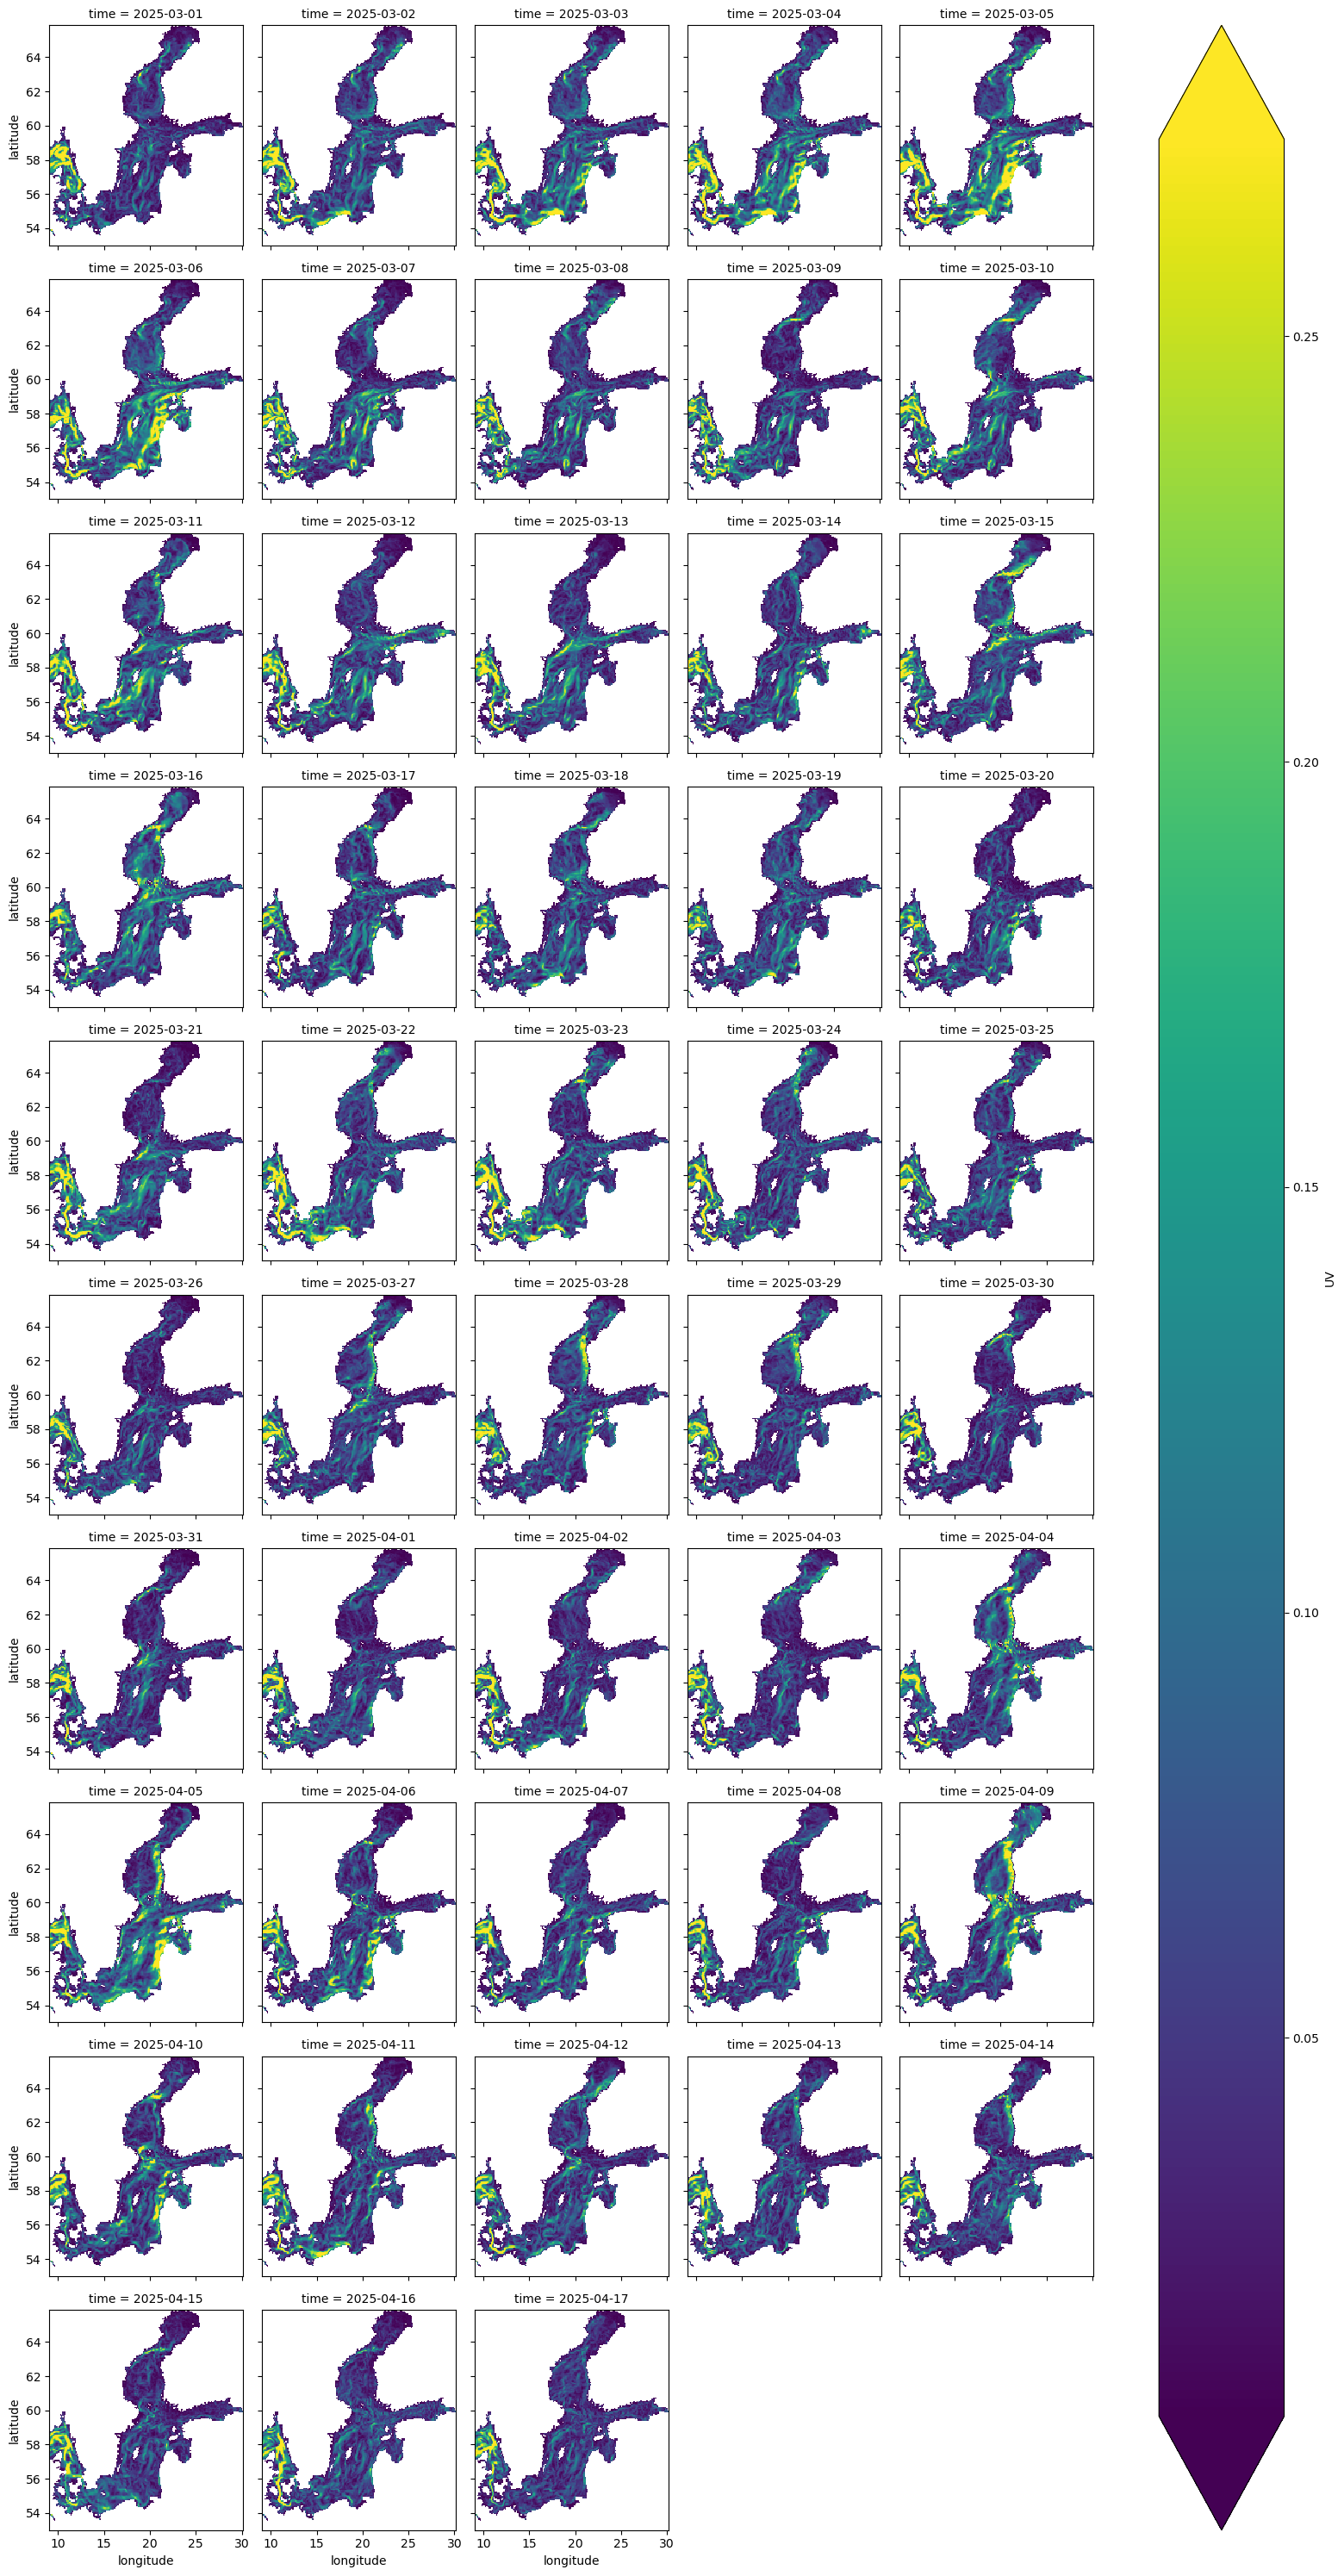

In [8]:
ds['UV'] = np.sqrt(ds.uo**2 + ds.vo**2)

# ds['UV'].plot(x="longitude", y="latitude", col="time", col_wrap=5)
# Coarsen the data before plotting
coarsening_factor = 4  # Adjust this based on your needs
ds_coarsened = ds['UV'].coarsen(
    longitude=coarsening_factor,
    latitude=coarsening_factor,
    boundary='trim'  # or 'pad' if you prefer
).mean()  # You can also use .max() or .min() depending on your needs

# Now plot the coarsened data
ds_coarsened.plot(
    x="longitude",
    y="latitude",
    col="time",
    col_wrap=5,
    robust=True  # Better color scaling for coarsened data
)

In [10]:
# Most straightforward method when your netCDF follows standard conventions
filenames = {
    'U': path1+fn,
    'V': path1+fn,
}
variables = {
    'U': 'uo',
    'V': 'vo'
}
dimensions = {
    'lon': 'longitude',
    'lat': 'latitude',
    'time': 'time'
}

fieldset = FieldSet.from_netcdf(filenames, 
                                variables, 
                                dimensions, 
                                allow_time_extrapolation=True)

In [11]:
##check the error
def CheckError(particle, fieldset, time):
    if particle.state >= 50:  # This captures all Errors
        particle.delete()

In [12]:
## parameters
from datetime import datetime, timedelta
## set the number of particles
num_particles = 1000

## Set the location of the particles
release_lons = np.linspace(15.75,15.755,num_particles) # use inmutable objects
release_lats= np.linspace(55.29,55.295,num_particles)
release_time = datetime(2025,4,13)

# ## set the tracking time
# days = 30
# minutes = 20

# ## record the particles every timestep of
# hours=4

In [13]:
# 3. Create ParticleSet for backtracking
pset = ParticleSet(fieldset=fieldset,
                   pclass=JITParticle,
                   lon=release_lons,
                   lat=release_lats,
                   time=release_time)

In [14]:
# 4. Configure backward simulation
backward_duration = timedelta(days=30)  # how far back you want to track
output_dt = timedelta(hours=1)          # output frequency
dt = timedelta(minutes=-10)  

In [15]:
out_fn = 'backtrack_eggs_BB23_13_4_2.zarr' #path to store the particle zarr
output_file = pset.ParticleFile(name=path1+out_fn, 
                              outputdt=output_dt)

In [10]:
pset.execute([AdvectionRK4,CheckError],
            runtime=backward_duration,
            dt=dt,
            output_file=output_file,
)  # handle particles going out of domain


INFO: Output files are stored in /gxfs_work/geomar/smomw662/ALKOR630/data/backtrack_eggs_BB23_13_4_2.zarr.
100%|████████████████████████████████████| 2592000.0/2592000.0 [00:06<00:00, 373070.85it/s]


### Plotting

In [16]:
import numpy as np
from matplotlib import pyplot as plt
from cmocean import cm # for oceanography-specific colormaps
from itertools import zip_longest
from functools import reduce
from operator import add
from pathlib import Path
import tqdm

In [17]:
out_fn2 = 'backtrack_eggs_BB23_8_4_2.zarr'
ds_traj = xr.open_zarr(path1+out_fn)
ds_traj = ds_traj.compute()
ds_traj

ds_traj2 = xr.open_zarr(path1+out_fn2)
ds_traj2 = ds_traj2.compute()
ds_traj2

<xarray.Dataset> Size: 608kB
Dimensions:     (trajectory: 1000, obs: 30)
Coordinates:
  * obs         (obs) int32 120B 0 1 2 3 4 5 6 7 8 ... 22 23 24 25 26 27 28 29
  * trajectory  (trajectory) int64 8kB 2000 2001 2002 2003 ... 2997 2998 2999
Data variables:
    lat         (trajectory, obs) float32 120kB 55.29 55.24 ... 54.94 54.91
    lon         (trajectory, obs) float32 120kB 15.75 15.75 ... 15.76 15.68
    time        (trajectory, obs) datetime64[ns] 240kB 2025-04-08 ... 2025-03-10
    z           (trajectory, obs) float32 120kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4CheckError
    parcels_mesh:           spherical
    parcels_version:        3.0.5

Text(0.5, 0.98, 'ALKOR 630 Station BB23')

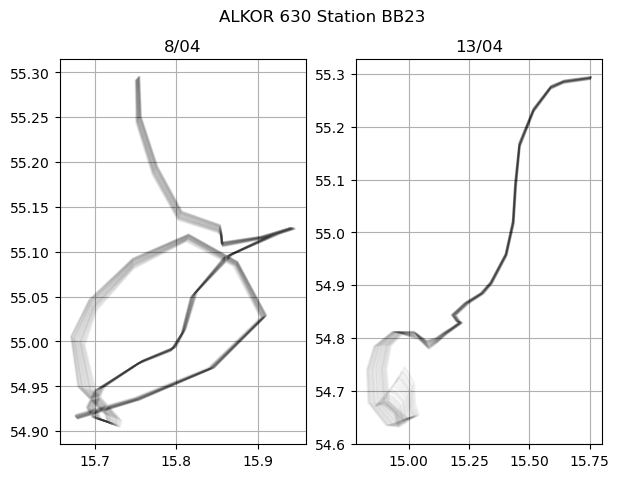

In [18]:
# plt.scatter(ds_traj.isel(obs=0).lon,ds_traj.isel(obs=0).lat)
# plt.scatter(ds_traj.lon,ds_traj.lat)

figure,ax = plt.subplots(1,2,figsize=(7,5))

for t in np.random.randint(0,1000,size=(100,)):
    ax[1].plot(ds_traj.isel(trajectory=t).lon, ds_traj.isel(trajectory=t).lat,'k-',alpha=0.01)
    ax[0].plot(ds_traj2.isel(trajectory=t).lon, ds_traj2.isel(trajectory=t).lat,'k-',alpha=0.01)

ax[0].set_title('8/04')
ax[0].grid(True)
ax[1].set_title('13/04')
ax[1].grid(True)

plt.suptitle('ALKOR 630 Station BB23')

In [20]:
lon_bins = np.linspace(ds_traj.lon.min().compute().data[()], ds_traj.lon.max().compute().data[()], 30)
lat_bins = np.linspace(ds_traj.lat.min().compute().data[()], ds_traj.lat.max().compute().data[()], 40)

obs_counts = xhist(
    ds_traj.lon,
    ds_traj.lat,
    bins=[lon_bins, lat_bins],
    dim=["trajectory", ],
    bin_dim_suffix=""
)

#---------------------------
lon_bins = np.linspace(ds_traj2.lon.min().compute().data[()], ds_traj2.lon.max().compute().data[()], 30)
lat_bins = np.linspace(ds_traj2.lat.min().compute().data[()], ds_traj2.lat.max().compute().data[()], 40)

obs_counts2 = xhist(
    ds_traj2.lon,
    ds_traj2.lat,
    bins=[lon_bins, lat_bins],
    dim=["trajectory", ],
    bin_dim_suffix=""
)
# obs_counts

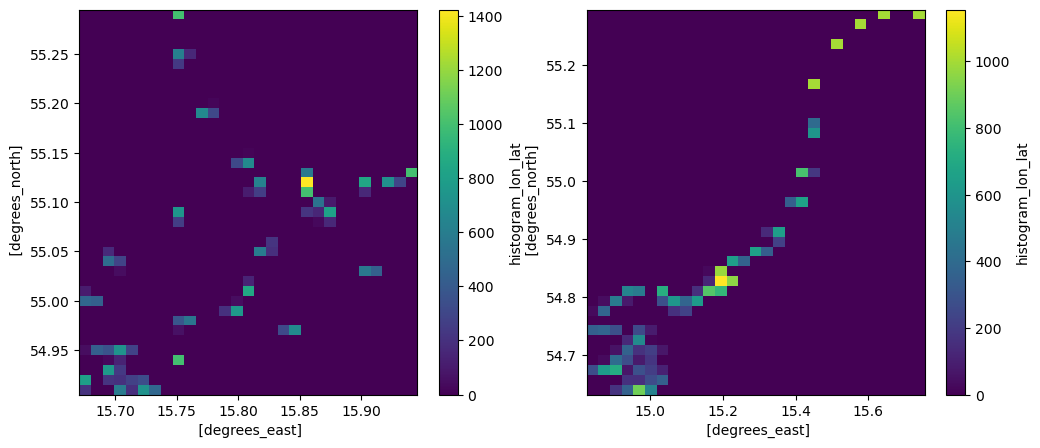

In [21]:
fig,ax = plt.subplots(1,2,figsize=(12,5))

obs_counts.sum('obs').plot(x='lon',y='lat',ax=ax[1])
obs_counts2.sum('obs').plot(x='lon',y='lat',ax=ax[0])


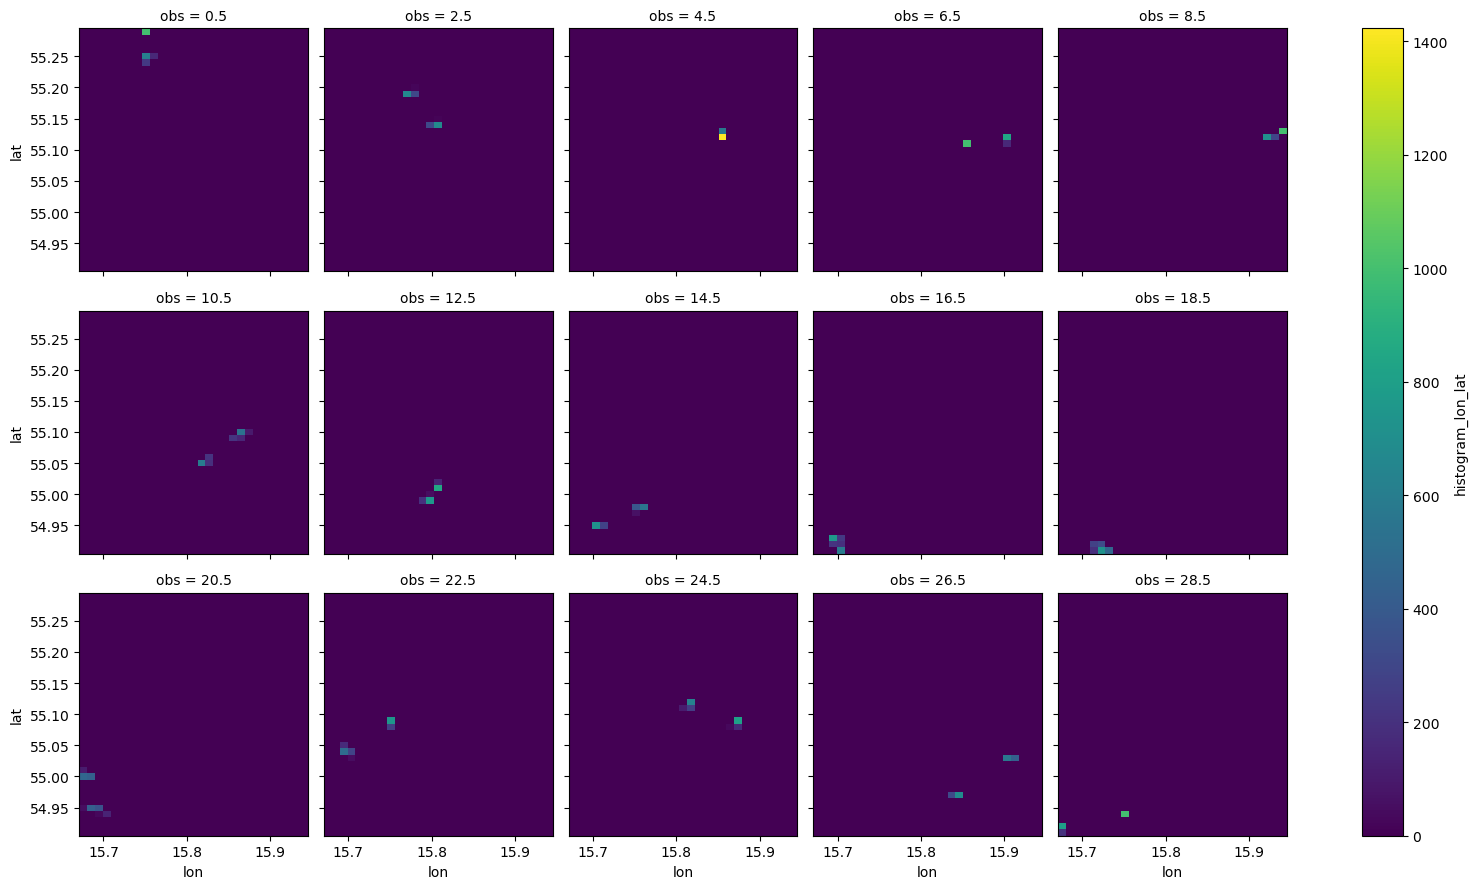

In [36]:
obs_counts2.coarsen(obs=2, boundary="trim").sum().plot(x="lon", y="lat", col="obs", col_wrap=5)

In [25]:
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Set up the figure
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.coastlines(resolution='10m')
ax.gridlines(draw_labels=True)

ax.set_extent([14, 16, 54, 56], crs=ccrs.PlateCarree())  # Adjusted for 54-56°N

# Add high-resolution coastline (50m or 10m)
ax.add_feature(cfeature.LAND, facecolor='lightgray')  # Solid land color
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.5)  # High-res coastline

ax.set_title('Particle Trajectory Animation')

# Initialize empty scatter plot
scatter = ax.scatter([], [], s=5, color='red', transform=ccrs.PlateCarree())

# Add faint background trajectories
for t in range(min(100, len(ds_traj.trajectory))):  # Limit to 100 trajectories
    ax.plot(ds_traj.isel(trajectory=t).lon, 
            ds_traj.isel(trajectory=t).lat, 
            'k-', alpha=0.02, transform=ccrs.PlateCarree())

# Animation update function
def update(frame):
    # Get all particle positions at current frame
    x = ds_traj.isel(obs=frame).lon.values
    y = ds_traj.isel(obs=frame).lat.values
    
    # Update scatter plot
    scatter.set_offsets(np.c_[x, y])
    
    # Update title
    ax.set_title(f'Egg drifters - Observation {frame}')
    return scatter,

# Create animation
animation = FuncAnimation(
    fig, 
    update, 
    frames=len(ds_traj.obs),  # Number of observation frames
    interval=100,             # Delay between frames in ms
    blit=True
)

# Close the figure to prevent double display
plt.close()

# Display animation in notebook
HTML(animation.to_html5_video())

In [29]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import cartopy.feature as cfeature
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Set up the figure
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([14.25, 16.25, 54, 56], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.5)
ax.gridlines(draw_labels=True)

# Initialize scatter plots for both datasets
scatter1 = ax.scatter([], [], s=5, color='red', label='Eggs 13/04', transform=ccrs.PlateCarree())
scatter2 = ax.scatter([], [], s=5, color='blue', label='Eggs 08/04', transform=ccrs.PlateCarree())

# Add faint background trajectories
for t in range(min(100, len(ds_traj.trajectory))):
    ax.plot(ds_traj.isel(trajectory=t).lon, ds_traj.isel(trajectory=t).lat, 
            'r-', alpha=0.02, transform=ccrs.PlateCarree())
for t in range(min(100, len(ds_traj2.trajectory))):
    ax.plot(ds_traj2.isel(trajectory=t).lon, ds_traj2.isel(trajectory=t).lat, 
            'b-', alpha=0.02, transform=ccrs.PlateCarree())

# Animation update function
def update(frame):
    # Update first dataset
    x1 = ds_traj.isel(obs=frame).lon.values
    y1 = ds_traj.isel(obs=frame).lat.values
    scatter1.set_offsets(np.c_[x1, y1])
    
    # Update second dataset
    x2 = ds_traj2.isel(obs=frame).lon.values
    y2 = ds_traj2.isel(obs=frame).lat.values
    scatter2.set_offsets(np.c_[x2, y2])
    
    ax.set_title(f'Backtracked Egg drifters ALKOR630 - Observation {frame}')
    return scatter1, scatter2

# Create animation (use the smaller number of frames if they differ)
min_frames = min(len(ds_traj.obs), len(ds_traj2.obs))
animation = FuncAnimation(
    fig, 
    update, 
    frames=min_frames,
    interval=100,
    blit=True
)

# Add legend
ax.legend(loc='upper right')

plt.close()
HTML(animation.to_html5_video())

# animation.save('particle_tracks.gif', 
#                writer='pillow',  # Requires pillow installed
#                fps=10,
#                dpi=100)